# This is for 6 mL : 4 mL ratio in room temperature

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
csv_path  = "M2_2.18mM_pressure_o2_release.csv"
time_col  = "Time (s)"                     # your column is actually hours
press_col = "DWT denoised pressure (kPa)"  # pressure in kPa
gas_col   = "O2 Released (µmol)"          # headspace O2 from csv
df = pd.read_csv(csv_path)
df.columns = [c.strip() for c in df.columns]

# Temperature according to time


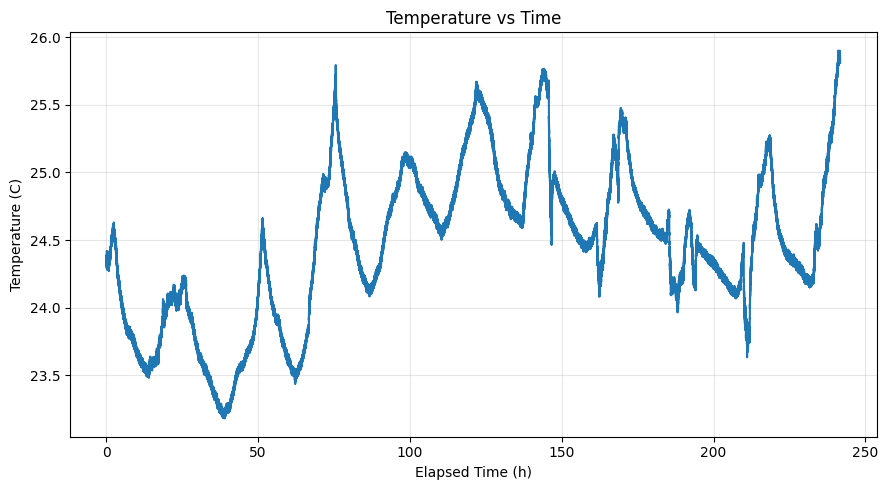

In [3]:
main_csv = r"M2_2.18mM_pressure_o2_release.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]
temperature_col = "calibrated temperature (C)"
time_col = "Time (s)"

t_h = pd.to_numeric(df_main[time_col], errors="coerce")
plt.figure(figsize=(9,5))
plt.plot(t_h, df_main[temperature_col], label="Temperature (C)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Temperature (C)")
plt.title("Temperature vs Time")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Pressure in atm


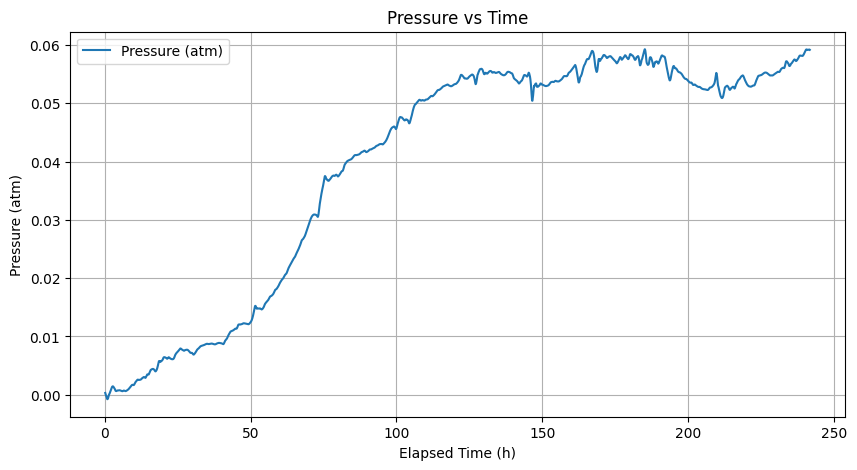

0.05928848133017262


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"M2_2.18mM_pressure_o2_release.csv"   # has Time, Pressure, Temp

df_main = pd.read_csv(main_csv)

df_main.columns = [c.strip() for c in df_main.columns]


pressure_col = df_main["DWT denoised pressure (kPa)"] / 101.325  # convert kPa to atm
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, pressure_col, label="Pressure (atm)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Pressure (atm)")
plt.title("Pressure vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(pressure_col))

# Headspace o2 detected by sensor

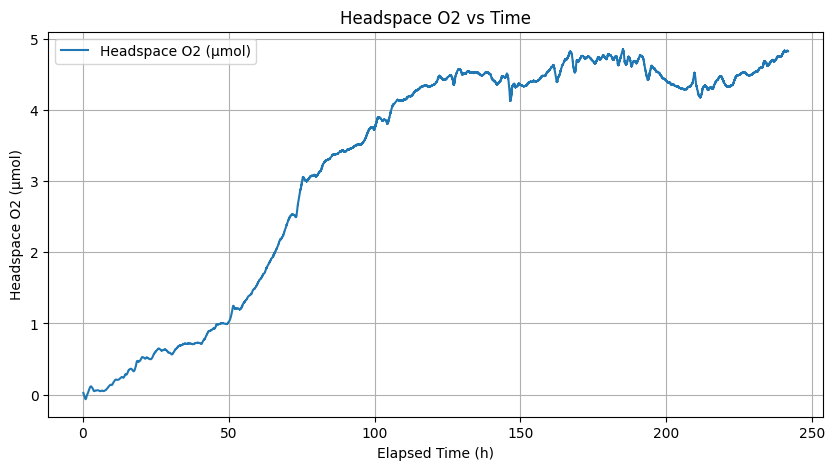

4.853248053248819


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



main_csv = r"M2_2.18mM_pressure_o2_release.csv"   # has Time, Pressure, Temp
df_main = pd.read_csv(main_csv)
df_main.columns = [c.strip() for c in df_main.columns]


headspace_oxygen = df_main["O2 Released (µmol)"]
time_col = df_main["Time (s)"] 

plt.figure(figsize=(10, 5))
plt.plot(time_col, headspace_oxygen, label="Headspace O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.ylabel("Headspace O2 (µmol)")
plt.title("Headspace O2 vs Time")
plt.legend()
plt.grid()
plt.show()

print(max(headspace_oxygen))

# Dissolved O2 in atm

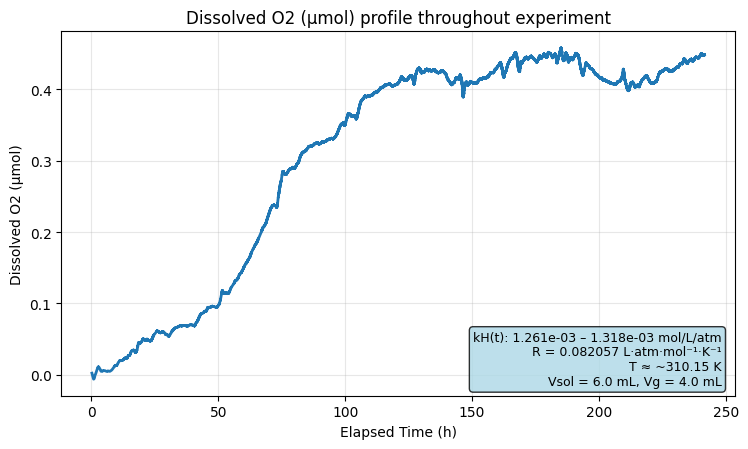

0.4578607752927767
0.4481385644717554


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- inputs ----------
main_csv   = r"M2_2.18mM_pressure_o2_release.csv"       
kh_csv     = r"C:\Users\chand\Documents\GitHub\Thesis\CSV files outputs\Vant hoff modelling\henry's constants.csv"
time_col   = "Time (s)"  
press_col  = "DWT denoised pressure (kPa)"                                  

# ---------- constants ----------
R = 0.082057            # L·atm·mol^-1·K^-1
T = 310.15              # K (37 °C) – used only for the info box
Vsol = 0.006            # L
Vg   = 0.004            # L

# ---------- load ----------
df = pd.read_csv(main_csv)
df.columns = [c.strip() for c in df.columns]
df_kh = pd.read_csv(kh_csv)
df_kh.columns = [c.strip() for c in df_kh.columns]
time_h = pd.to_numeric(df[time_col], errors="coerce")
p_kpa  = pd.to_numeric(df[press_col], errors="coerce")
kH_time = df_kh["kH_mol_per_L_atm"]
p_atm = p_kpa / 101.325    # convert kPa to atm


n_aq_umol = (kH_time * Vsol * p_atm) * 1e6    # dissolved O2 from Henry (µmol)

# ---------- assemble output ----------
df_out = pd.DataFrame({
    "Elapsed Time (h)": time_h,
    "p_kpa (kPa)": p_kpa,
    "p_atm (atm)": p_atm,
    "kH (mol/L/atm)": kH_time,
    "n_aq (µmol)": n_aq_umol
})

# ---------- plot ----------
plt.figure(figsize=(7.6, 4.6))
plt.plot(df_out["Elapsed Time (h)"], df_out["n_aq (µmol)"], linewidth=2)
plt.ylabel("Dissolved O2 (µmol)")
plt.xlabel("Elapsed Time (h)")
plt.title("Dissolved O2 (µmol) profile throughout experiment")

kH_min, kH_max = float(np.nanmin(kH_time)), float(np.nanmax(kH_time))
info_text = (
    f"kH(t): {kH_min:.3e} – {kH_max:.3e} mol/L/atm\n"
    f"R = {R} L·atm·mol⁻¹·K⁻¹\n"
    f"T ≈ ~{T:.2f} K\n"
    f"Vsol = {Vsol*1000:.1f} mL, Vg = {Vg*1000:.1f} mL"
)
plt.text(0.98, 0.02, info_text,
         transform=plt.gca().transAxes,
         va="bottom", ha="right", fontsize=9,
         bbox=dict(boxstyle="round", facecolor="lightblue", alpha=0.8))

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(max(n_aq_umol))
print(n_aq_umol.iloc[-1])